<a href="https://colab.research.google.com/github/atilimai/plant-ai-project/blob/main/notebooks/Ilgin_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Aktif Cihaz: {device} 🚀")

Aktif Cihaz: cuda 🚀


In [12]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

image_dir = "PlantVillage-Dataset/raw/color"
image_paths = glob.glob(os.path.join(image_dir, "**/*.JPG"), recursive=True) + \
              glob.glob(os.path.join(image_dir, "**/*.png"), recursive=True)

if len(image_paths) == 0:
    raise FileNotFoundError("Görseller bulunamadı, lütfen klasör yolunu kontrol edin.")

data_list = []
for img_path in image_paths:
    # Klasör ismini doğrudan hastalık adı (multiclass_name) olarak alıyoruz
    folder_name = img_path.split(os.sep)[-2]

    data_list.append({
        "image_path": img_path,
        "multiclass_name": folder_name
    })

df = pd.DataFrame(data_list)

# Sınıf isimlerini sayısal etiketlere (0, 1, 2...) çevirip kaydedelim
df['multiclass_label'] = df['multiclass_name'].astype('category').cat.codes
class_map = dict(enumerate(df['multiclass_name'].astype('category').cat.categories))
num_classes = len(class_map)

print(f"=== VERİ ÖZETİ ===")
print(f"Toplam bulunan görsel sayısı: {len(df)}")
print(f"Toplam benzersiz hastalık sınıfı sayısı: {num_classes}")

# Ekip liderinin istediği sızıntısız (stratify) bölme: %80 Train, %20 Test
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['multiclass_label']
)

# %80'lik Train kısmının %15'ini Validation (Doğrulama) yapıyoruz
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df['multiclass_label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\n=== BÖLME İŞLEMİ BAŞARILI ===")
print(f"Eğitim (Train) seti boyutu: {len(train_df)}")
print(f"Doğrulama (Val) seti boyutu: {len(val_df)}")
print(f"Test seti boyutu: {len(test_df)}")

=== VERİ ÖZETİ ===
Toplam bulunan görsel sayısı: 52804
Toplam benzersiz hastalık sınıfı sayısı: 38

=== BÖLME İŞLEMİ BAŞARILI ===
Eğitim (Train) seti boyutu: 35906
Doğrulama (Val) seti boyutu: 6337
Test seti boyutu: 10561


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

# Orijinal kodundaki transform yapısını doğrudan buraya tanımlıyoruz
multiclass_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PlantDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        # Çoklu sınıf etiketini alıyoruz
        label = self.df.iloc[idx]['multiclass_label']

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# Dataset nesnelerini yeni oluşturduğumuz multiclass_transform ile kuruyoruz
train_dataset = PlantDataset(train_df, transform=multiclass_transform)
val_dataset = PlantDataset(val_df, transform=multiclass_transform)
test_dataset = PlantDataset(test_df, transform=multiclass_transform)

# DataLoader'ları ayağa kaldırıyoruz
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("=== VERİ YÜKLEYİCİLER HAZIR ===")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

=== VERİ YÜKLEYİCİLER HAZIR ===
Train batches: 1123
Validation batches: 199
Test batches: 331


In [16]:
import torch
import torch.nn as nn
import torchvision.models as models

# Hem eski hem yeni torchvision versiyonlarıyla uyumlu MobileNetV2 mimarisi
class PlantMobileNetModel(nn.Module):
    def __init__(self, num_classes=38):
        super(PlantMobileNetModel, self).__init__()

        # Versiyon hatasını engellemek için try-except bloğu ile modeli güvenli yüklüyoruz
        try:
            self.backbone = models.mobilenet_v2(weights=models.MobileNetV2_Weights.DEFAULT)
        except AttributeError:
            # Eğer torchvision eski versiyonsa bu parametre çalışacaktır
            self.backbone = models.mobilenet_v2(pretrained=True)

        # MobileNetV2'nin orijinal sınıflandırma kafasındaki giriş özellik sayısını alıyoruz
        in_features = self.backbone.classifier[1].in_features

        # Son katmanı bizim 38 adet multiclass sınıfımıza çıktı verecek şekilde güncelliyoruz
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# Cihaz kontrolü (GPU/CUDA aktifse ona taşır)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modeli 38 sınıfımız için ayağa kaldırıyoruz
model = PlantMobileNetModel(num_classes=38).to(device)

print("=== MODEL MİMARİSİ HAZIR ===")
print(f"Model başarıyla oluşturuldu ve cihaza ({device}) gönderildi.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 143MB/s]


=== MODEL MİMARİSİ HAZIR ===
Model başarıyla oluşturuldu ve cihaza (cuda) gönderildi.


In [17]:
import torch.optim as optim
import json

# Klasörlerin varlığından emin olalım (Liderin istediği yollar)
os.makedirs("models/checkpoints", exist_ok=True)
os.makedirs("configs", exist_ok=True)

# 1. Kayıp Fonksiyonu ve Optimizasyon Tanımı
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Hiperparametreleri ekip liderinin istediği gibi configs klasörüne kaydedelim
config_data = {
    "model_architecture": "MobileNetV2",
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 3,
    "num_classes": 38
}
with open("configs/experiment_config.json", "w") as f:
    json.dump(config_data, f, indent=4)

epochs = 3
best_val_loss = float('inf')

print("=== EĞİTİM BAŞLIYOR ===")
for epoch in range(epochs):
    # --- EĞİTİM (TRAINING) ADIMI ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train

    # --- DOĞRULAMA (VALIDATION) ADIMI ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * correct_val / total_val

    print(f"Epoch [{epoch+1}/{epochs}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    # En iyi modeli (Best Checkpoint) bulup kaydetme
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "models/checkpoints/best_model.pth")
        print("-> En iyi model checkpoint'i başarıyla güncellendi ve 'models/checkpoints/best_model.pth' konumuna kaydedildi.")

print("\n=== EĞİTİM TAMAMLANDI ===")

=== EĞİTİM BAŞLIYOR ===
Epoch [1/3] -> Train Loss: 0.5457 | Train Acc: 83.43% | Val Loss: 0.2864 | Val Acc: 90.41%
-> En iyi model checkpoint'i başarıyla güncellendi ve 'models/checkpoints/best_model.pth' konumuna kaydedildi.
Epoch [2/3] -> Train Loss: 0.2577 | Train Acc: 91.98% | Val Loss: 0.1507 | Val Acc: 95.11%
-> En iyi model checkpoint'i başarıyla güncellendi ve 'models/checkpoints/best_model.pth' konumuna kaydedildi.
Epoch [3/3] -> Train Loss: 0.2041 | Train Acc: 93.50% | Val Loss: 0.1775 | Val Acc: 94.21%

=== EĞİTİM TAMAMLANDI ===


In [ ]:
os.makedirs('models/checkpoints', exist_ok=True)
os.makedirs('artifacts/figures', exist_ok=True)
os.makedirs('artifacts/reports', exist_ok=True)

model_path = "models/checkpoints/binary_baseline_model.pth"
torch.save(model.state_dict(), model_path)
print(f"Model başarıyla '{model_path}' konumuna kaydedildi! 💾")

Model başarıyla 'models/checkpoints/binary_baseline_model.pth' konumuna kaydedildi! 💾


=== TEST SETİ DEĞERLENDİRİLİYOR ===

=== MULTICLASS CLASSIFICATION REPORT ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.94      0.95       126
                                 Apple___Black_rot       0.96      0.99      0.98       124
                          Apple___Cedar_apple_rust       0.96      0.98      0.97        55
                                   Apple___healthy       0.94      0.97      0.96       329
                               Blueberry___healthy       0.99      0.95      0.97       300
          Cherry_(including_sour)___Powdery_mildew       0.95      1.00      0.97       210
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.34      0.50        89
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
 

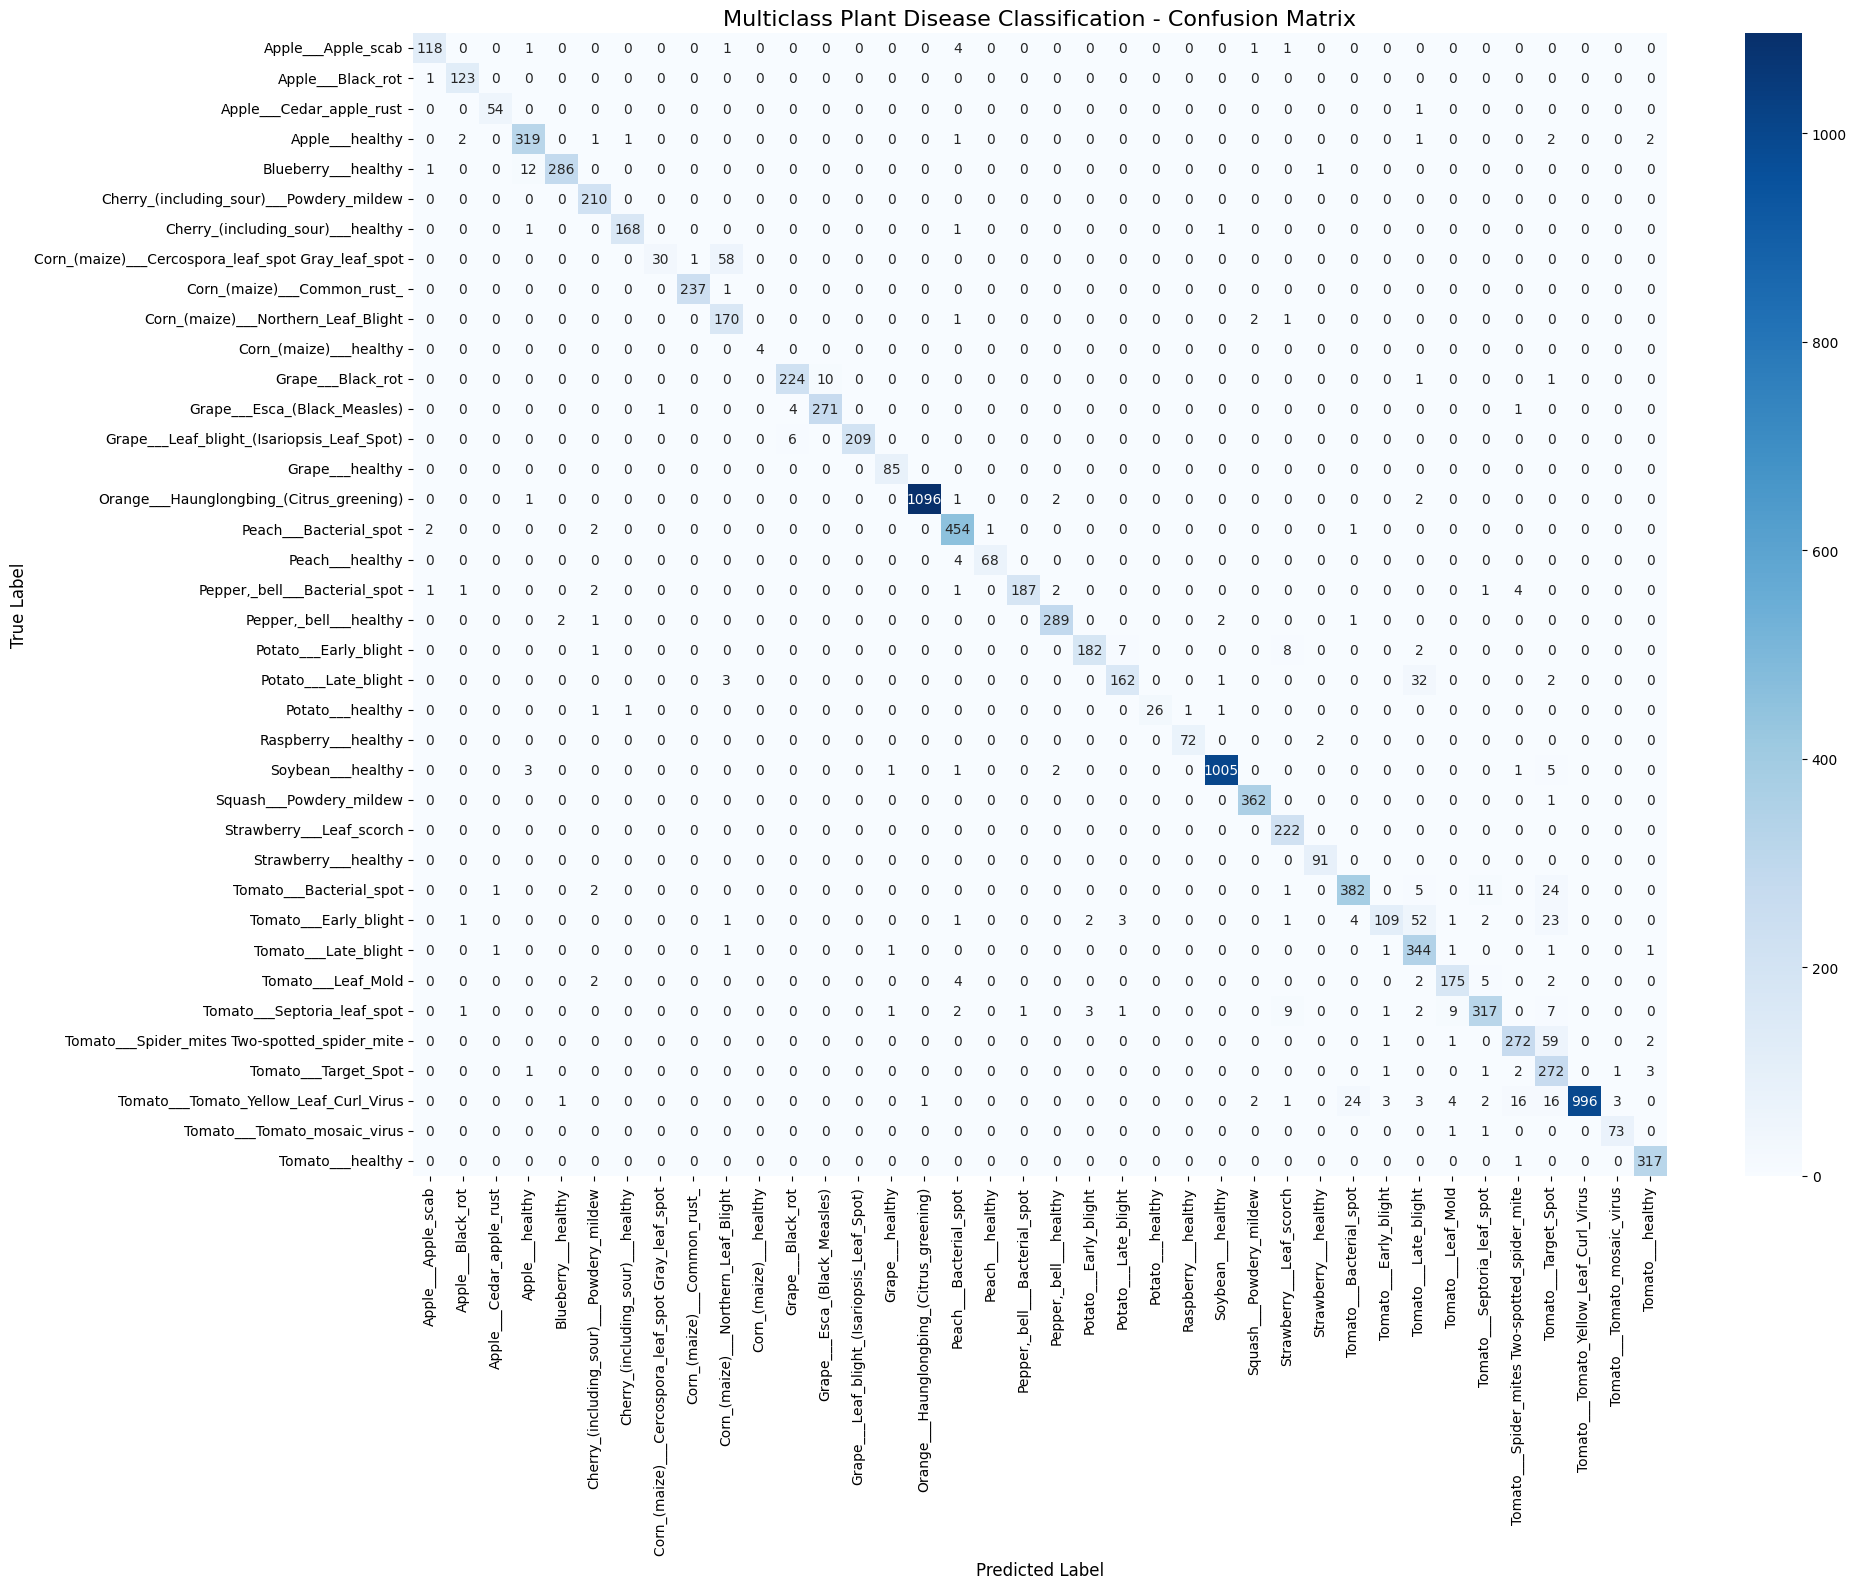


=== TEBRİKLER! TÜM GÖREVLER BAŞARIYLA TAMAMLANDI ===


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Gerekli kayıt klasörlerini oluşturalım
os.makedirs("artifacts/figures", exist_ok=True)
os.makedirs("artifacts/reports", exist_ok=True)

# 1. En iyi model ağırlıklarını geri yüklüyoruz (Lider kriteri #4)
model.load_state_dict(torch.load("models/checkpoints/best_model.pth"))
model.eval()

all_preds = []
all_labels = []

print("=== TEST SETİ DEĞERLENDİRİLİYOR ===")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Metriklerin Raporlanması (Lider kriteri #5, #6, #8)
# class_map'ten sınıf isimlerini alıyoruz
target_names = [class_map[i] for i in range(len(class_map))]

report = classification_report(all_labels, all_preds, target_names=target_names)
print("\n=== MULTICLASS CLASSIFICATION REPORT ===")
print(report)

# Raporu ekip liderinin istediği klasör yoluna kaydedelim
with open("artifacts/reports/multiclass_classification_report.txt", "w") as f:
    f.write(report)
print("-> Sınıflandırma raporu 'artifacts/reports/multiclass_classification_report.txt' konumuna kaydedildi.")

# 3. Multiclass Confusion Matrix Çizimi ve Kaydedilmesi (Lider kriteri #7)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 16)) # 38 sınıf olduğu için grafiği büyük çizdiriyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Multiclass Plant Disease Classification - Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

# Grafiği liderin istediği klasöre kaydedelim
plt.savefig("artifacts/figures/confusion_matrix.png", dpi=300)
print("-> Çoklu sınıf hata matrisi grafiği 'artifacts/figures/confusion_matrix.png' olarak kaydedildi.")
plt.show()

print("\n=== TEBRİKLER! TÜM GÖREVLER BAŞARIYLA TAMAMLANDI ===")